In [ ]:
from IPython.display import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import cv2

import torch
from diffusers import SanaPipeline

In [2]:
seed = 42
torch.random.manual_seed(seed)

CACHE_DIR = "/mnt/sda3/Documents/Models/" # change this to where you want to download the pipeline

# Sampling pipeline

In [3]:
pipe = SanaPipeline.from_pretrained(
    "Efficient-Large-Model/SANA_600M_1024px_diffusers",
    cache_dir=CACHE_DIR,
    variant="fp16",
    torch_dtype=torch.bfloat16,
)
pipe.to("cuda")

pipe.vae.to(torch.bfloat16)
pipe.text_encoder.to(torch.bfloat16)

print("model loaded!")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

model loaded!


In [4]:
prompt = "Kramer stands in a kitchen, his body facing forward and his head turned slightly to his right. He holds his right hand up beside his head, his index finger pointed straight up in a classic \"aha\" or \"listen to me\" gesture, the other fingers curled into his palm. He wears a rugged, dark chocolate-brown leather or suede jacket with a wide, soft collar, the fabric rich and slightly worn, the jacket left open in the front. Beneath it, he has on a soft, long-sleeved button-down shirt in a warm, glowing shade of amber, apricot, or pale orange, the collar open and the shirt slightly rumpled. The background reveals a pantry or kitchen: to the right, dark gray or black cabinets with glass doors display a collection of colorful cans and food containers, including a distinctive yellow-orange can, while to the left, an open shelf holds more boxes and packages, and a small calendar or note with red, white, and blue stripes is pinned to a surface below. The lighting is warm and slightly dim, with a soft golden cast that enhances the amber tones of his shirt and the rich brown of his jacket."

In [5]:
with torch.no_grad():
    prompt_embeds, prompt_attention_mask, negative_prompt_embeds, negative_prompt_attention_mask = pipe.encode_prompt(
        prompt=prompt,
        do_classifier_free_guidance=True,
        negative_prompt="",
        num_images_per_prompt=1,
        device="cuda",
    )

prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)
prompt_attention_mask = torch.cat([negative_prompt_attention_mask, prompt_attention_mask], dim=0)

In [6]:
vae_scale_factor = 2 ** (len(pipe.vae.config.encoder_block_out_channels) - 1)
height, width = 768, 1024

pipe.scheduler.set_timesteps(20, device="cuda")
timesteps = pipe.scheduler.timesteps

latents = torch.randn(
    1,
    pipe.transformer.config.in_channels,
    height // vae_scale_factor,
    width // vae_scale_factor,
    device="cuda",
    dtype=torch.float32,
    generator=torch.Generator(device="cuda").manual_seed(seed),
)

In [7]:
progress = []

with torch.no_grad():
    transformer_dtype = pipe.transformer.dtype
    for i, t in enumerate(tqdm(timesteps)):
        latent_model_input = torch.cat([latents] * 2)
        timestep = t.expand(latent_model_input.shape[0]) * pipe.transformer.config.timestep_scale

        noise_pred = pipe.transformer(
            latent_model_input.to(dtype=transformer_dtype),
            encoder_hidden_states=prompt_embeds.to(dtype=transformer_dtype),
            encoder_attention_mask=prompt_attention_mask,
            timestep=timestep,
            return_dict=False,
        )[0].float()

        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + 4.5 * (noise_pred_text - noise_pred_uncond)

        if pipe.transformer.config.out_channels // 2 == pipe.transformer.config.in_channels:
            noise_pred = noise_pred.chunk(2, dim=1)[0]

        latents = pipe.scheduler.step(noise_pred, t, latents, return_dict=False)[0]

        # decode latents back to images for debug
        latents_dec = latents.to(pipe.vae.dtype)
        image_dec = pipe.vae.decode(
            latents_dec / pipe.vae.config.scaling_factor, return_dict=False
        )[0]
        image_dec = pipe.image_processor.postprocess(image_dec, output_type="pil")[0]
        progress.append(image_dec)

100%|██████████| 20/20 [00:06<00:00,  2.98it/s]


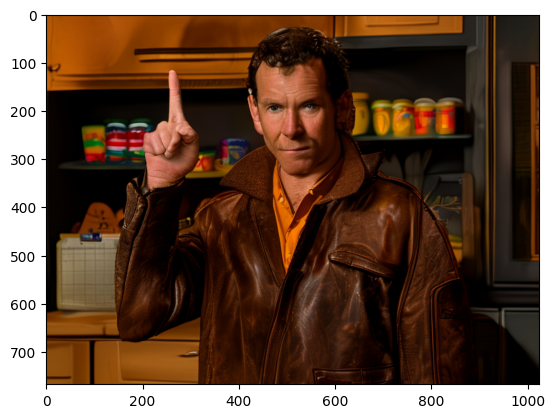

In [8]:
with torch.no_grad():
    latents = latents.to(pipe.vae.dtype)
    image = pipe.vae.decode(latents / pipe.vae.config.scaling_factor, return_dict=False)[0]
    image = pipe.image_processor.postprocess(image, output_type="pil")[0]

plt.imshow(image)

# Denoising progress

In [9]:
fps = 24
size = progress[0].size
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("output.mp4", fourcc, fps, size)

for img in progress:
    frame = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    out.write(frame)

out.release()

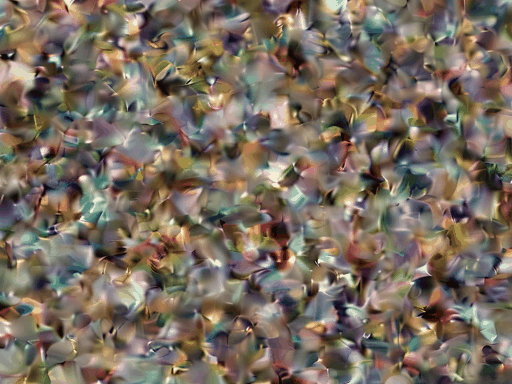

In [ ]:
resized_progress = [img.resize((img.width // 2, img.height // 2)) for img in progress]

resized_progress[0].save(
    "out.gif",
    save_all=True,
    append_images=resized_progress[1:],
    duration=100,
    loop=0,
    optimize=True,
)

Image(filename="out.gif")